In [1]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
import torch
import matplotlib.pyplot as plt
import seaborn as sns

/Users/arpe/miniconda3/envs/bertopic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
posts_data = pd.read_csv("../data/fb_data_with_predictions.csv")
highlevel_unions = pd.read_csv("../data/mapping_fb_unions.csv")
highlevel_unions = highlevel_unions.dropna(subset=["account_match"])
highlevel_unions_handles = highlevel_unions[["union", "account_match"]]
highlevel_unions_handles.columns = ["main_union", "handle"]

posts_data = posts_data.merge(highlevel_unions_handles, how="left", left_on="surface.username", right_on="handle")


# IAFF

In [58]:
union = "iaff"

In [59]:
posts_by_union = posts_data[posts_data["main_union"] == union]
posts_texts = posts_by_union["text"].dropna().tolist()

In [60]:
posts_by_union_nonan = posts_by_union.dropna(subset=["text"])

In [61]:
# remove duplicates
posts_texts = list(set(posts_texts))

In [62]:
sentence_model = SentenceTransformer("all-distilroberta-v1") # not sure this truncates long text automatically, in our case we have less than 1% of data which is too long.
representation_model = KeyBERTInspired()
umap = UMAP(random_state=0)
hdbscan_model = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

topic_model_iaff = BERTopic(embedding_model=sentence_model, representation_model=representation_model, umap_model=umap, hdbscan_model=hdbscan_model)

In [63]:
# Set seeds and deterministic settings
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

embeddings = sentence_model.encode(posts_texts, batch_size=64, show_progress_bar=True)


Batches: 100%|██████████| 105/105 [00:39<00:00,  2.63it/s]


In [64]:
topic_model_iaff.fit(posts_texts, embeddings=embeddings)

Inspect topic, then merge

In [65]:
info_topics_iaff = topic_model_iaff.get_topic_info()
info_topics_iaff

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1502,-1_firefighters_congress_vote_conference,"[firefighters, congress, vote, conference, org...",[Every IAFF member across our two countries be...
1,0,1582,0_iaffmayorsfireops_firefighters_iaff_org,"[iaffmayorsfireops, firefighters, iaff, org, c...","[In a special Point of Privilege, General Pres..."
2,1,524,1_firefightercancerawarenessmonth_firefighters...,"[firefightercancerawarenessmonth, firefighters...",[From Edward A. Kelly IAFF General President :...
3,2,454,2_fighters_fire_iaffrecoverycenter_iaff,"[fighters, fire, iaffrecoverycenter, iaff, res...",[The IAFF Center of Excellence for Behavioral ...
4,3,344,3_iaffsafetytips_emergency_fire_fireworks,"[iaffsafetytips, emergency, fire, fireworks, h...",[Keep your pets safe this holiday season by fo...
5,4,299,4_firefighters_hurricane_fire_fighters,"[firefighters, hurricane, fire, fighters, supp...",[Throughout what has been an extremely active ...
6,5,277,5_firefighters_fighters_rescue_ca,"[firefighters, fighters, rescue, ca, fire, 197...",[FLASHBACK FRIDAY - 2018 - A unique perspectiv...
7,6,185,6_firefighters_fighters_fire_fdny,"[firefighters, fighters, fire, fdny, fighter, ...",[The 30th IAFF Fallen Fire Fighter Memorial se...
8,7,162,7_firefighters_fire_fighters_fairfax,"[firefighters, fire, fighters, fairfax, alsawa...","[Los Angeles County, CA Local 1014 a top fundr..."
9,8,150,8_iaffcentennialconvention_iaffconvention_conv...,"[iaffcentennialconvention, iaffconvention, con...","[See the #IAFF56th recap of Day 1 from Ottawa,..."


In [ ]:
info_topics_iaff.to_csv(f"../data/topic_info_{union}.csv", index=False)

In [68]:
topic_groups = {"Info on union leaders and events": [0, 8],
                "Disease awareness": [1, 7, 9],
                "Promotion of union centers/services": [2, 14, 15],
                "Sharing safety tips": [3],
                "Union stories, solidarity and memories": [4, 5, 6, 11, 17, 18],
                "COVID-19 efforts": [10],
                "IAFF media awards": [13],
                "Promotion of registration for events and reminders for deadlines": [12, 16, 19, 21],
                "Fight for/against a bill": [20]
                }

In [71]:
topics_to_merge = list(topic_groups.values())

In [72]:
topics_to_merge

[[0, 8],
 [1, 7, 9],
 [2, 14, 15],
 [3],
 [4, 5, 6, 11, 17, 18],
 [10],
 [13],
 [12, 16, 19, 21],
 [20]]

In [73]:
topic_model_iaff.merge_topics(posts_texts, topics_to_merge)

In [74]:
topic_model_iaff.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1502,-1_firefighters_fighters_responders_congress,"[firefighters, fighters, responders, congress,...",[The International Association of Fire Fighter...
1,0,1732,0_firefighters_fighters_union_iaffmayorsfireops,"[firefighters, fighters, union, iaffmayorsfire...",[Edward A. Kelly addresses delegates as the ne...
2,1,1014,1_firefighters_support_rescue_fund,"[firefighters, support, rescue, fund, hurrican...","[Overnight, at least 30 tornadoes were reporte..."
3,2,828,2_firefighters_ffcancermonth_fightffcancer_fir...,"[firefighters, ffcancermonth, fightffcancer, f...",[Learn more about cancer in the fire service a...
4,3,654,3_iaffrecoverycenter_treatment_iaff_recovery,"[iaffrecoverycenter, treatment, iaff, recovery...",[June is Post-Traumatic Stress Awareness Month...
5,4,344,4_iaffsafetytips_safe_safety_tips,"[iaffsafetytips, safe, safety, tips, halloween...","[Be safe this holiday season! #IAFFSafetyTips,..."
6,5,312,5_conference_events_registration_event,"[conference, events, registration, event, regi...",[TRAINING ALERT🚨: Reserve your spot for the 20...
7,6,138,6_coronavirus_data_responders_vaccines,"[coronavirus, data, responders, vaccines, surv...",[The IAFF is urging affiliate presidents to co...
8,7,110,7_iaffmediaawardscontest_iaffmediaawards_iaffm...,"[iaffmediaawardscontest, iaffmediaawards, iaff...",[Congratulations to the winners in the 2020 IA...
9,8,51,8_cosponsors_congress_senate_bipartisan,"[cosponsors, congress, senate, bipartisan, law...",[Utah Senator Mike Lee is preventing a vote on...


In [ ]:
topic_model_iaff.get_topic_info().to_csv(f"../data/topic_info_{union}_merged.csv", index=False) # working file

In [76]:
new_labels = {
    -1: "Noise",
    0: "General info on union",
    1: "Union stories or events",
    2: "Disease awareness",
    3: "Promotion of union services",
    4: "Sharing safety tips",
    5: "Registration for events",
    6: "COVID-19 efforts",
    7: "IAFF media awards",
    8: "Fight for/against a bill",
}

topic_model_iaff.set_topic_labels(new_labels)

# save model

In [ ]:
topic_model_iaff.save("../models/iaff_topic_model", serialization="pickle")

2025-12-12 17:30:50,598 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
# load model
#topic_model_iaff = BERTopic.load("../models/iaff_topic_model")


In [88]:
dataframe_topics = topic_model_iaff.get_document_info(posts_texts)

In [89]:
dataframe_topics

,Document,Topic,Name,CustomName,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,The 4th District Caucus and PEP Training Event...,5,5_conference_events_registration_event,Registration for events,"[conference, events, registration, event, regi...",[TRAINING ALERT🚨: Reserve your spot for the 20...,conference - events - registration - event - r...,1.000000,False
1,Tell Rep. Justin Amash remembering 9/11 should...,-1,-1_firefighters_fighters_responders_congress,Noise,"[firefighters, fighters, responders, congress,...",[The International Association of Fire Fighter...,firefighters - fighters - responders - congres...,0.000000,False
2,Registration is now open for #IAFFLegCon March...,-1,-1_firefighters_fighters_responders_congress,Noise,"[firefighters, fighters, responders, congress,...",[The International Association of Fire Fighter...,firefighters - fighters - responders - congres...,0.000000,False
3,"🇺🇸 On this #VeteransDay, we pay tribute and e...",-1,-1_firefighters_fighters_responders_congress,Noise,"[firefighters, fighters, responders, congress,...",[The International Association of Fire Fighter...,firefighters - fighters - responders - congres...,0.000000,False
4,"Bristol, VA #firefighters facing cuts address ...",0,0_firefighters_fighters_union_iaffmayorsfireops,General info on union,"[firefighters, fighters, union, iaffmayorsfire...",[Edward A. Kelly addresses delegates as the ne...,firefighters - fighters - union - iaffmayorsfi...,1.000000,False
...,...,...,...,...,...,...,...,...,...
6680,Registration for Fit To Thrive (F2T) workshops...,5,5_conference_events_registration_event,Registration for events,"[conference, events, registration, event, regi...",[TRAINING ALERT🚨: Reserve your spot for the 20...,conference - events - registration - event - r...,0.712237,False
6681,"Rochester, NH Local 1451 #FilltheBoot",2,2_firefighters_ffcancermonth_fightffcancer_fir...,Disease awareness,"[firefighters, ffcancermonth, fightffcancer, f...",[Learn more about cancer in the fire service a...,firefighters - ffcancermonth - fightffcancer -...,0.847745,False
6682,"🔥🏛️ ERS UPDATE \n\nTomorrow, the U.S. Departme...",-1,-1_firefighters_fighters_responders_congress,Noise,"[firefighters, fighters, responders, congress,...",[The International Association of Fire Fighter...,firefighters - fighters - responders - congres...,0.000000,False
6683,Our Fit To Thrive program aims to make exercis...,3,3_iaffrecoverycenter_treatment_iaff_recovery,Promotion of union services,"[iaffrecoverycenter, treatment, iaff, recovery...",[June is Post-Traumatic Stress Awareness Month...,iaffrecoverycenter - treatment - iaff - recove...,0.617609,False


In [80]:
merged_df = posts_by_union_nonan.merge(dataframe_topics[["Document", "Topic", "CustomName", "Representation"]], left_on="text", right_on="Document", how="left")

In [ ]:
# save
merged_df.to_csv(f"../data/iaff_posts_with_merged_topics.csv", index=False) # working file

In [91]:
frame_cols = ["diagnostic", "prognostic", "motivational",
              "community", "engagement"]

In [92]:
overall_topic_counts = merged_df["CustomName"].value_counts(normalize=True)
overall_topic_counts

CustomName
General info on union          0.249053
Noise                          0.224358
Union stories or events        0.147327
Disease awareness              0.121510
Promotion of union services    0.096394
Sharing safety tips            0.064684
Registration for events        0.049951
COVID-19 efforts               0.021608
IAFF media awards              0.016697
Fight for/against a bill       0.008419
Name: proportion, dtype: float64

In [93]:
# select only topic that have overall at least 5% representation
selected_topics = overall_topic_counts[overall_topic_counts >= 0.05].index.tolist()

In [94]:
frame_emotion_matrix = {}

for frame in frame_cols:
    frame_posts = merged_df[merged_df[frame] == 1]   # posts with this frame
    # get distribution of topics
    topic_counts = frame_posts["CustomName"].value_counts(normalize=True)
    frame_emotion_matrix[frame] = topic_counts

frame_emotion_df = pd.DataFrame(frame_emotion_matrix).fillna(0)

# Make sure row indices match between the two
frame_emotion_df = frame_emotion_df.reindex(overall_topic_counts.index, fill_value=0)

# Convert to NumPy arrays for broadcasting
overall = overall_topic_counts.values[:, None]       # shape (n_topics, 1)
frame_vals = frame_emotion_df.values                 # shape (n_topics, n_frames)

# Apply correction
adjusted_vals = ((frame_vals - overall) / overall)*100

# Convert back to DataFrame with same index/columns
adjusted_frame_emotion_df = pd.DataFrame(
    adjusted_vals,
    index=overall_topic_counts.index,
    columns=frame_emotion_df.columns
)

adjusted_frame_emotion_df = adjusted_frame_emotion_df.loc[selected_topics]

In [95]:
adjusted_frame_emotion_df = adjusted_frame_emotion_df[adjusted_frame_emotion_df.index.str.startswith("Noise") == False]

In [111]:
# change names in CustomName
new_names = {
    "General info on union": "General info\non union",
    "Union stories or events": "Union stories\nor events",
    "Disease awareness": "Disease\nawareness",
    "Promotion of union services": "Promotion of\nunion services",
    "Sharing safety tips": "Sharing\nsafety tips"}
adjusted_frame_emotion_df.rename(index=new_names, inplace=True)

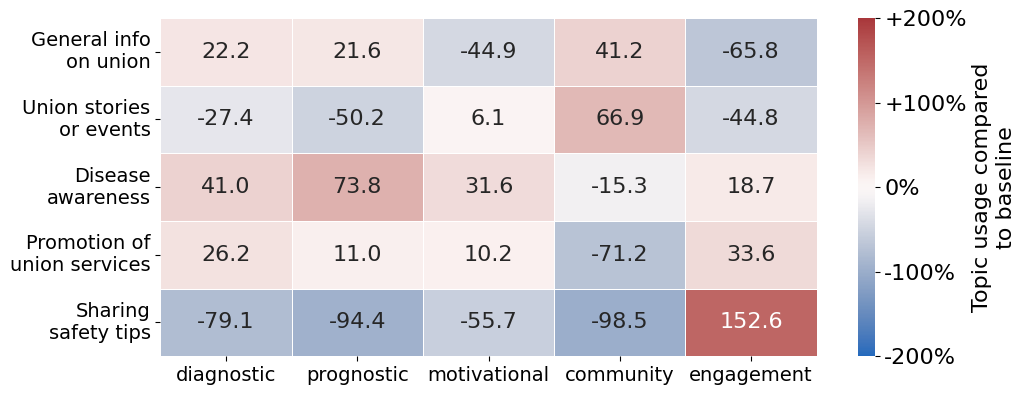

In [ ]:
plt.figure(figsize=(10, 4))

ax = sns.heatmap(
    adjusted_frame_emotion_df,
    annot=True,          
    fmt=".1f",           
    cmap="vlag",       
    vmin=-200,
    vmax=200,
    center = 0,
    linewidths=0.5,
    cbar_kws={'label': 'Topic usage compared\nto baseline'},
    annot_kws={"fontsize": 16}

)

colorbar = ax.collections[0].colorbar
colorbar.set_label('Topic usage compared\nto baseline', fontsize=16)
colorbar.set_ticks([-200, -100, 0, 100, 200])
colorbar.set_ticklabels(["-200%", "-100%", "0%", "+100%", "+200%"], fontsize=16)
colorbar.ax.yaxis.set_tick_params(labelleft=False)

plt.ylabel("")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f"../plots/topic_modeling_byunion_{union}.svg")

# SEIU

In [130]:
union = "seiu"

In [131]:
posts_by_union = posts_data[posts_data["main_union"] == union]
posts_texts = posts_by_union["text"].dropna().tolist()
# remove duplicates
posts_texts = list(set(posts_texts))

In [132]:
posts_by_union_nonan = posts_by_union.dropna(subset=["text"])

In [133]:
sentence_model = SentenceTransformer("all-distilroberta-v1") # not sure this truncates long text automatically, in our case we have less than 1% of data which is too long.
representation_model = KeyBERTInspired()
umap = UMAP(random_state=0) 
hdbscan_model = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

topic_model_seiu = BERTopic(embedding_model=sentence_model, representation_model=representation_model, umap_model=umap, hdbscan_model=hdbscan_model)

In [134]:
# Set seeds and deterministic settings
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
embeddings = sentence_model.encode(posts_texts, batch_size=64, show_progress_bar=True)


Batches: 100%|██████████| 160/160 [00:43<00:00,  3.69it/s]


In [137]:
topic_model_seiu.fit(posts_texts, embeddings=embeddings)

Inspect topic, then merge

In [138]:
info_topic_seiu = topic_model_seiu.get_topic_info()
info_topic_seiu

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2919,-1_unionsforall_unions_union_strike,"[unionsforall, unions, union, strike, wages, h...","[""In sickness and in health.""\n\nGetting sick ..."
1,0,2308,0_unionsforall_workers_wages_wage,"[unionsforall, workers, wages, wage, labor, wo...","[We’re fighting so all workers—Black, white & ..."
2,1,659,1_congress_republicans_vote_republican,"[congress, republicans, vote, republican, sena...",[The fight against healthcare repeal is back a...
3,2,492,2_wages_workers_families_union,"[wages, workers, families, union, congress, wo...",[The Trump administration wants to deny home c...
4,3,451,3_stimulus4workers_unemployment_republicans_he...,"[stimulus4workers, unemployment, republicans, ...",[Nursing home workers are going ON STRIKE for ...
5,4,412,4_congress_immigrant_immigration_immigrants,"[congress, immigrant, immigration, immigrants,...","[In his first week in the White House, Preside..."
6,5,402,5_congress_union_povertydoesntfly_wages,"[congress, union, povertydoesntfly, wages, wor...","[11,000 airport catering workers will vote on ..."
7,6,345,6_unionsforall_unionize_solidarity_sbworkersun...,"[unionsforall, unionize, solidarity, sbworkers...",[Shoutout to Starbucks baristas rallying in Bu...
8,7,274,7_racialjustice_rights_strikeforblacklives_wor...,"[racialjustice, rights, strikeforblacklives, w...",[We’ve been fighting to win justice for all wo...
9,8,272,8_unionsforall_solidarity_union_unions,"[unionsforall, solidarity, union, unions, work...",[The SEIU Faculty Forward Movement is continui...


In [ ]:
info_topic_seiu.to_csv(f"../data/topic_info_{union}.csv", index=False) # working file

In [140]:
topic_groups = {"Reasons to join a union": [0, 14],
                "Support or opposition for bill": [1, 4, 13, 15, 18, 21],
                "Rights for workers": [2, 3, 5, 7, 10, 17, 20],
                "Support and solidarity for ongoing strikes": [6, 8, 11, 14, 16, 19, 24],
                "Vote for US congress and support candidates": [9, 12, 23],
                "Other": [22]
                }

In [141]:
topics_to_merge = list(topic_groups.values())

In [142]:
topic_model_seiu.merge_topics(posts_texts, topics_to_merge)

In [143]:
topic_model_seiu.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2919,-1_unionsforall_unions_union_workers,"[unionsforall, unions, union, workers, wages, ...","[Service and care workers, like those that car..."
1,0,2308,0_unionsforall_unions_union_wages,"[unionsforall, unions, union, wages, workers, ...",[Appreciation post for the folks at Kickstarte...
2,1,1966,1_protectallworkers_union_workers_home,"[protectallworkers, union, workers, home, work...",[Home care workers take care of your loved one...
3,2,1443,2_savemedicaid_medicaid_congress_healthcare,"[savemedicaid, medicaid, congress, healthcare,...",[House Republicans are in a rush to vote on th...
4,3,1094,3_unionsforall_union_solidarity_workers,"[unionsforall, union, solidarity, workers, str...",[The workers of Amazon.com are making history ...
5,4,414,4_seiuforhillary_elect_hillary_election,"[seiuforhillary, elect, hillary, election, can...","[In 28 states from coast to coast, thousands o..."
6,5,58,5_said_simple_just_way,"[said, simple, just, way, right, this, to, pss...","[Pssst. It doesn’t have to be this way., It do..."


In [ ]:
topic_model_seiu.get_topic_info().to_csv(f"../data/topic_info_{union}_merged.csv", index=False)

In [145]:
new_labels = {
    -1: "Noise",
    0: "Reasons to join a union",
    1: "Rights for workers",
    2: "Fight for bill",
    3: "Support for strikes",
    4: "Vote for US congress",
    5: "Other"
}


topic_model_seiu.set_topic_labels(new_labels)

In [ ]:
topic_model_seiu.save("../models/seiu_topic_model", serialization="pickle")

2025-12-12 17:58:14,340 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
# load model
#topic_model_seiu = BERTopic.load("../models/seiu_topic_model")


In [148]:
dataframe_topics = topic_model_seiu.get_document_info(posts_texts)

In [149]:
dataframe_topics

,Document,Topic,Name,CustomName,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,"Care is an issue that affects all of us, no ma...",1,1_protectallworkers_union_workers_home,Rights for workers,"[protectallworkers, union, workers, home, work...",[Home care workers take care of your loved one...,protectallworkers - union - workers - home - w...,1.000000,False
1,The way the rules are rigged will in fact make...,-1,-1_unionsforall_unions_union_workers,Noise,"[unionsforall, unions, union, workers, wages, ...","[Service and care workers, like those that car...",unionsforall - unions - union - workers - wage...,0.000000,False
2,"🗣️ There is no labor shortage, There is a shor...",0,0_unionsforall_unions_union_wages,Reasons to join a union,"[unionsforall, unions, union, wages, workers, ...",[Appreciation post for the folks at Kickstarte...,unionsforall - unions - union - wages - worker...,1.000000,False
3,Watch this video and see how a coalition of la...,-1,-1_unionsforall_unions_union_workers,Noise,"[unionsforall, unions, union, workers, wages, ...","[Service and care workers, like those that car...",unionsforall - unions - union - workers - wage...,0.000000,False
4,The Supreme Court could make a decision anytim...,-1,-1_unionsforall_unions_union_workers,Noise,"[unionsforall, unions, union, workers, wages, ...","[Service and care workers, like those that car...",unionsforall - unions - union - workers - wage...,0.000000,False
...,...,...,...,...,...,...,...,...,...
10197,🔴 WATCH NOW! Arizona home care workers & consu...,1,1_protectallworkers_union_workers_home,Rights for workers,"[protectallworkers, union, workers, home, work...",[Home care workers take care of your loved one...,protectallworkers - union - workers - home - w...,1.000000,False
10198,We will not accept laws meant to silence Black...,2,2_savemedicaid_medicaid_congress_healthcare,Fight for bill,"[savemedicaid, medicaid, congress, healthcare,...",[House Republicans are in a rush to vote on th...,savemedicaid - medicaid - congress - healthcar...,1.000000,False
10199,"Colorado home care workers Melissa Benjamin, B...",2,2_savemedicaid_medicaid_congress_healthcare,Fight for bill,"[savemedicaid, medicaid, congress, healthcare,...",[House Republicans are in a rush to vote on th...,savemedicaid - medicaid - congress - healthcar...,0.866223,False
10200,If you believe that having a fair shot to join...,0,0_unionsforall_unions_union_wages,Reasons to join a union,"[unionsforall, unions, union, wages, workers, ...",[Appreciation post for the folks at Kickstarte...,unionsforall - unions - union - wages - worker...,0.973696,False


In [150]:
merged_df = posts_by_union_nonan.merge(dataframe_topics[["Document", "Topic", "CustomName", "Representation"]], left_on="text", right_on="Document", how="left")

In [ ]:
# save
merged_df.to_csv(f"../data/seiu_posts_with_merged_topics.csv", index=False) # working file

In [152]:
frame_cols = ["diagnostic", "prognostic", "motivational",
              "community", "engagement"]

In [153]:
overall_topic_counts = merged_df["CustomName"].value_counts(normalize=True)
overall_topic_counts

CustomName
Noise                      0.284922
Reasons to join a union    0.226751
Rights for workers         0.193551
Fight for bill             0.142365
Support for strikes        0.106487
Vote for US congress       0.040088
Other                      0.005836
Name: proportion, dtype: float64

In [154]:
# select only topic that have overall at least 5% representation
selected_topics = overall_topic_counts[overall_topic_counts >= 0.05].index.tolist()

In [155]:
frame_emotion_matrix = {}

for frame in frame_cols:
    frame_posts = merged_df[merged_df[frame] == 1]   # posts with this frame
    # get distribution of topics
    topic_counts = frame_posts["CustomName"].value_counts(normalize=True)
    frame_emotion_matrix[frame] = topic_counts

frame_emotion_df = pd.DataFrame(frame_emotion_matrix).fillna(0)

# Make sure row indices match between the two
frame_emotion_df = frame_emotion_df.reindex(overall_topic_counts.index, fill_value=0)

# Convert to NumPy arrays for broadcasting
overall = overall_topic_counts.values[:, None]       # shape (n_topics, 1)
frame_vals = frame_emotion_df.values                 # shape (n_topics, n_frames)

# Apply correction
adjusted_vals = ((frame_vals - overall) / overall)*100

# Convert back to DataFrame with same index/columns
adjusted_frame_emotion_df = pd.DataFrame(
    adjusted_vals,
    index=overall_topic_counts.index,
    columns=frame_emotion_df.columns
)

adjusted_frame_emotion_df = adjusted_frame_emotion_df.loc[selected_topics]

In [156]:
adjusted_frame_emotion_df = adjusted_frame_emotion_df[adjusted_frame_emotion_df.index.str.startswith("Noise") == False]

In [157]:
# change names in CustomName
new_names = {
    "Reasons to join a union": "Reasons to\njoin a union",
    "Rights for workers": "Rights\nfor workers",
    "Fight for bill": "Fight for bill",
    "Support for strikes": "Support\nfor strikes"}
adjusted_frame_emotion_df.rename(index=new_names, inplace=True)

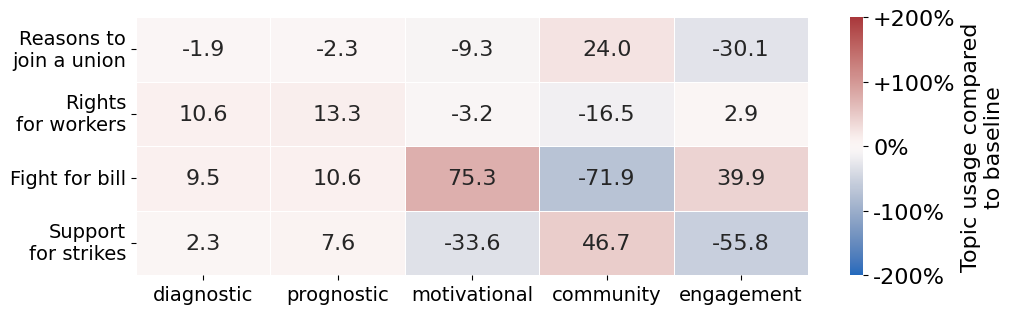

In [ ]:
plt.figure(figsize=(10, 3.2))

ax = sns.heatmap(
    adjusted_frame_emotion_df,
    annot=True,         
    fmt=".1f",           
    cmap="vlag",       
    vmin=-200,
    vmax=200,
    center = 0,
    linewidths=0.5,
    cbar_kws={'label': 'Topic usage compared\nto baseline'},
    annot_kws={"fontsize": 16}

)

colorbar = ax.collections[0].colorbar
colorbar.set_label('Topic usage compared\nto baseline', fontsize=16)
colorbar.set_ticks([-200, -100, 0, 100, 200])
colorbar.set_ticklabels(["-200%", "-100%", "0%", "+100%", "+200%"], fontsize=16)
colorbar.ax.yaxis.set_tick_params(labelleft=False)

#plt.title("Emotion Distribution by Frame", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f"../plots/topic_modeling_byunion_{union}.svg")